# TSMC advanced multi-strategy trading laboratory

Five strategy specialists feed a causal adaptive router: trend pullbacks, range reversion, price breakouts, compression breakouts and model consensus. A single-position execution engine applies whole-share sizing, ATR risk budgets, partial exits, trailing stops, overnight gap handling, holding limits and account drawdown controls.

**Historical optimization is fitted to the reported windows.** The earlier-selected comparison excludes the final 44 observations from parameter selection, but this dataset has already been examined. Neither is a guarantee of future profits. All windows start independently with $100,000.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, importlib.util, sys, inspect, warnings, json
import torch
import xgboost as xgb
from IPython.display import display

INITIAL_CAPITAL = 100000.0
LOOKBACK = 30  # legacy loader fallback; checkpoint metadata takes precedence
COMMISSION_BPS = 5.0
SLIPPAGE_BPS = 5.0
BORROW_ANNUAL = 0.03
WINDOWS = {"weekly": 5, "monthly": 22, "two_months": 44}
MAIN_WINDOW = "monthly"
STRATEGY_MODE = "historical_fit"  # or "prewindow_selected"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore")

DATASET = r"F:\SEM-7\Time Series Analysis\Project\Data\TSMC_Master_Features_15Y.csv"
ROOT = r"F:\SEM-7\Time Series Analysis\Project\models"

PATHS = {
    "ARIMA": rf"{ROOT}\arima\20260923T021526961853Z",
    "SARIMA": rf"{ROOT}\sarima\20260923T033954075995Z",
    "LSTM": rf"{ROOT}\lstm\20260923T041634383000Z",
    "Transformer": rf"{ROOT}\transformer\20260927T035006308666Z",
    "XGBoost": rf"{ROOT}\xgboost\20260927T040834645810Z",
    "Stacking": rf"{ROOT}\stacking\20260927T042412093647Z"}

OUTPUT_DIR = Path(DATASET).parent.parent / "Trading" / "advanced_report"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Original model loader and preprocessing helpers

In [ ]:
models = {}
pre    = {}
meta   = {}

def load_python_module(folder):
    py = Path(folder) / "model_definition.py"
    if not py.exists():
        return None

    unique_name = f"model_def_{abs(hash(str(py)))}"
    spec = importlib.util.spec_from_file_location(unique_name, py)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[unique_name] = mod
    spec.loader.exec_module(mod)
    return mod

def load_torch_checkpoint(folder):
    path = Path(folder) / "selected_model.pt"

    # weights_only=False is needed because the checkpoint contains metadata
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(payload, dict):
        if "state_dict" in payload:
            state_dict = payload["state_dict"]
            metadata = {k: v for k, v in payload.items() if k != "state_dict"}
        elif "model_state_dict" in payload:
            state_dict = payload["model_state_dict"]
            metadata = {k: v for k, v in payload.items() if k != "model_state_dict"}
        else:
            # Raw state_dict
            state_dict = payload
            metadata = {}
    else:
        return payload, {}

    return state_dict, metadata

def find_torch_classes(module):
    if module is None:
        return []
    classes = []
    for name, obj in module.__dict__.items():
        if (isinstance(obj, type) and issubclass(obj, torch.nn.Module) and obj is not torch.nn.Module):
            classes.append((name, obj))
    return classes

def infer_lstm_shape(state_dict):
    hidden_size = None
    num_layers = 1
    input_size = None

    for key, value in state_dict.items():
        if key.startswith("lstm.weight_ih_l0"):
            # PyTorch LSTM: [4*hidden_size, input_size]
            hidden_size = value.shape[0] // 4
            input_size = value.shape[1]

        if key.startswith("lstm.weight_ih_l"):
            try:
                idx = int(key.split("_l")[-1].split(".")[0])
                num_layers = max(num_layers, idx + 1)
            except:
                pass

    return input_size, hidden_size, num_layers

def select_class(classes, architecture):
    if architecture:
        arch = str(architecture).lower()
        for name, cls in classes:
            if str(name).lower() == arch:
                return cls
            if arch in str(name).lower() or str(name).lower() in arch:
                return cls

    # Prefer the classes that match what your artifacts reported.
    preferred = ["PriceCorrectionLSTM", "CompactFTTransformer", "LSTM", "Transformer"]
    for p in preferred:
        for name, cls in classes:
            if p.lower() == name.lower():
                return cls

    return classes[0][1] if classes else None

def instantiate_from_metadata(module, state_dict, metadata):
    classes = find_torch_classes(module)
    if not classes:
        raise RuntimeError("No torch.nn.Module class found in model_definition.py")

    architecture = metadata.get("architecture")

    if architecture is None and isinstance(metadata.get("model_config"), dict):
        architecture = metadata["model_config"].get("architecture")

    cls = select_class(classes, architecture)
    if cls is None:
        raise RuntimeError("Could not identify the model class.")

    config = {}
    if isinstance(metadata.get("model_config"), dict):
        config.update(metadata["model_config"])

    # Top-level checkpoint values override missing config fields.
    for k, v in metadata.items():
        if k not in ["state_dict", "model_config"]:
            config.setdefault(k, v)

    # Infer LSTM dimensions directly from the saved weights.
    inferred_input, inferred_hidden, inferred_layers = infer_lstm_shape(state_dict)

    if inferred_input is not None:
        config.setdefault("input_size", inferred_input)
    if inferred_hidden is not None:
        config.setdefault("hidden_size", inferred_hidden)
    if inferred_layers is not None:
        config.setdefault("num_layers", inferred_layers)

    sig = inspect.signature(cls.__init__)

    kwargs = {}

    for name, param in list(sig.parameters.items())[1:]:
        if name in config:
            kwargs[name] = config[name]

    # Useful aliases.
    aliases = {"input_dim": ["input_size"],"feature_dim": ["input_size"],"d_model": ["embedding_dim", "hidden_size"],
               "seq_len": ["lookback", "window_size"],"window_size": ["seq_len", "lookback"]}

    for name, param in list(sig.parameters.items())[1:]:
        if name in kwargs:
            continue
        for alias in aliases.get(name, []):
            if alias in config:
                kwargs[name] = config[alias]
                break

    # Safe defaults only where constructor defaults are absent.
    fallback = {"output_size": 1,"target_size": 1,"num_classes": 1,
                "dropout": 0.0,"batch_first": True,"max_len": LOOKBACK,
                "seq_len": LOOKBACK,"lookback": LOOKBACK,"window_size": LOOKBACK}

    for name, param in list(sig.parameters.items())[1:]:
        if name not in kwargs and name in fallback:
            kwargs[name] = fallback[name]

    # If a required Transformer nhead is absent, try sensible divisors of d_model.
    required_missing = [name for name, param in list(sig.parameters.items())[1:] if param.default is inspect._empty and name not in kwargs]
    # One common case: nhead is not stored explicitly.
    if "nhead" in required_missing:
        d_model = (kwargs.get("d_model") or config.get("d_model") or config.get("hidden_size"))

        if d_model is not None:
            for candidate in [8, 4, 2, 16, 1]:
                if d_model % candidate == 0:
                    kwargs["nhead"] = candidate
                    break

    missing = [
        name for name, param in list(sig.parameters.items())[1:]
        if param.default is inspect._empty and name not in kwargs
    ]

    if missing:
        raise RuntimeError(
            f"Required constructor arguments still missing for {cls.__name__}: {missing}. "
            f"Checkpoint metadata keys: {list(metadata.keys())}"
        )

    model = cls(**kwargs)

    # load_state_dict may have buffers or renamed keys; fail loudly if not exact.
    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()

    return model, metadata, cls.__name__, kwargs

def load_all_models():
    loaded = {}

    for name, folder in PATHS.items():
        folder = Path(folder)

        # preprocessing artifact
        pfile = folder / "preprocessing.joblib"
        pre[name] = joblib.load(pfile) if pfile.exists() else None

        if name in ["ARIMA", "SARIMA"]:
            loaded[name] = joblib.load(folder / "selected_model.pkl")
            meta[name] = {}

        elif name == "XGBoost":
            booster = xgb.Booster()
            booster.load_model(str(folder / "selected_model.ubj"))
            loaded[name] = booster
            meta[name] = {}

        elif name == "Stacking":
            # The saved meta-model alone cannot recreate the ensemble.
            # We retain it but exclude it from consensus until final_bases are loaded.
            loaded[name] = joblib.load(folder / "selected_meta.joblib")
            meta[name] = {"inference_status": "meta_model_only"}

        else:
            module = load_python_module(folder)
            state_dict, metadata = load_torch_checkpoint(folder)

            model, metadata, class_name, ctor_kwargs = instantiate_from_metadata(module,state_dict,metadata)
            loaded[name] = model
            meta[name] = {**metadata,"class_name": class_name,"constructor_kwargs": ctor_kwargs}

    return loaded

models = load_all_models()

print("\nLoaded models:")
for name, model in models.items():
    print(f"  {name:12s} -> {type(model).__name__}")
    if name in ["LSTM", "Transformer"]:
        print("     architecture:", meta[name].get("architecture"))
        print("     features    :", meta[name].get("features"))
        print("     target      :", meta[name].get("target"))
        print("     constructor :", meta[name].get("constructor_kwargs"))



Loaded models:
  ARIMA        -> ARIMAResultsWrapper
  SARIMA       -> SARIMAXResultsWrapper
  LSTM         -> PriceCorrectionLSTM
     architecture: {'id': 'close_only_w20_h64_l1', 'feature_set': 'close_only', 'lookback': 20, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1}
     features    : ['Close']
     target      : next trading day unadjusted Close
     constructor : {'input_size': 1, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0}
  Transformer  -> CompactFTTransformer
     architecture: None
     features    : ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Close', 'Return_1D', 'Log_Return_1D', 'High_Low_Range', 'Open_Close_Change', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Close_Lag_20', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10', 'Return_Lag_20', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Momentum_5D', 'Momentum_10D', 'Momentum_20D', 'Day_of_Week', '

In [ ]:

# ------------------------- PREPROCESSING HELPERS -------------------------

def find_feature_list(name):
    m = meta.get(name, {})

    if isinstance(m.get("features"), (list, tuple)):
        return list(m["features"])

    if isinstance(m.get("model_config"), dict):
        cfg = m["model_config"]
        if isinstance(cfg.get("features"), (list, tuple)):
            return list(cfg["features"])

    if name == "XGBoost":
        booster_features = models[name].feature_names
        if booster_features:
            return list(booster_features)

    return None

def apply_preprocessor(preprocessor, X):
    if preprocessor is None:
        return np.asarray(X, dtype=np.float32)

    # Common case: sklearn transformer / pipeline.
    if hasattr(preprocessor, "transform"):
        return preprocessor.transform(X)

    # Common serialized-dictionary patterns.
    if isinstance(preprocessor, dict):
        for key in [
            "feature_preprocessor",
            "feature_scaler",
            "x_scaler",
            "scaler",
            "preprocessor",
            "transformer",
        ]:
            obj = preprocessor.get(key)
            if obj is not None and hasattr(obj, "transform"):
                return obj.transform(X)

    raise RuntimeError(
        f"Unsupported preprocessing object for model: {type(preprocessor)}"
    )

def inverse_target_if_possible(name, y):
    """Use an explicitly saved target scaler if one exists.
    Otherwise leave the model output unchanged.
    """
    p = pre.get(name)

    if isinstance(p, dict):
        for key in [
            "target_scaler",
            "y_scaler",
            "close_scaler",
            "target_preprocessor",
        ]:
            obj = p.get(key)
            if obj is not None and hasattr(obj, "inverse_transform"):
                arr = np.asarray(y).reshape(-1, 1)
                return obj.inverse_transform(arr).ravel()

    return np.asarray(y).ravel()

def build_sequences(matrix, lookback):
    X = []
    for i in range(lookback, len(matrix)):
        X.append(matrix[i-lookback:i])
    return np.asarray(X, dtype=np.float32)


## Align origins and targets before inference

In [ ]:
df = pd.read_csv(DATASET)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
assert df.Date.is_unique and df.Date.is_monotonic_increasing
assert np.isfinite(df[["Open", "High", "Low", "Close"]]).all().all()
assert (df[["Open", "High", "Low", "Close"]] > 0).all().all()
manifest = json.loads((Path(PATHS["LSTM"]) / "manifest.json").read_text())
split = next(s for s in manifest["splits"] if s["split"] == "test")
origin_rows = np.flatnonzero(df.Date.between(pd.Timestamp(split["first_origin"]), pd.Timestamp(split["last_origin"])))
assert len(origin_rows) == split["rows"] and origin_rows[-1] + 1 == len(df)-1
origin = df.iloc[origin_rows].reset_index(drop=True)
target = df.iloc[origin_rows+1].reset_index(drop=True)
assert (origin.Date < target.Date).all()
print(f"Forecasts: {len(origin)} | final target: {target.Date.iloc[-1].date()}")
for label, count in WINDOWS.items():
    assert 0 < count <= len(target)
    print(label, count, target.Date.iloc[-count].date(), 'to', target.Date.iloc[-1].date())


Forecasts: 559 | final target: 2026-09-10
weekly 5 2026-09-03 to 2026-09-10
monthly 22 2026-08-11 to 2026-09-10
two_months 44 2026-07-10 to 2026-09-10


## Fresh saved-model forecasts and independent parity audit

In [ ]:
preds = {}
for name in ["ARIMA", "SARIMA"]:
    state = models[name]
    assert not state.model.k_exog, "This run requires its training exogenous-input preparation."
    values = []
    for actual in target.Close:
        values.append(float(np.asarray(state.forecast(1)).ravel()[0]))
        state = state.extend(np.array([actual]))
    preds[name] = np.asarray(values)
features = models["XGBoost"].feature_names
x = origin[features].copy()
if pre["XGBoost"] is not None:
    x = apply_preprocessor(pre["XGBoost"], x)
preds["XGBoost"] = origin.Close.to_numpy() + models["XGBoost"].predict(xgb.DMatrix(x, feature_names=features))
for name in ["LSTM", "Transformer"]:
    features = meta[name]["features"]
    values = df[features].astype(float).copy()
    if pre[name].get("volume_transform") == "log1p" and "Volume" in features:
        values["Volume"] = np.log1p(values["Volume"])
    scaled = pre[name]["x_scaler"].transform(values).astype(np.float32)
    anchors = pre[name]["y_scaler"].transform(df[["Close"]].to_numpy()).ravel().astype(np.float32)
    if name == "LSTM":
        lookback = int(meta[name]["architecture"]["lookback"])
        inputs = np.stack([scaled[i-lookback+1:i+1] for i in origin_rows])
    else:
        inputs = scaled[origin_rows]
    assert np.isfinite(inputs).all()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(inputs), 64):
            x = torch.as_tensor(inputs[start:start+64], device=DEVICE)
            a = torch.as_tensor(anchors[origin_rows[start:start+64]], device=DEVICE)
            outputs.append(models[name](x, a).cpu().numpy().ravel())
    preds[name] = pre[name]["y_scaler"].inverse_transform(np.concatenate(outputs).reshape(-1,1)).ravel()
# Stacking remains loaded exactly as before, but its meta-model is not a complete inference pipeline.
audit = []
for name, prediction in preds.items():
    assert len(prediction) == len(origin) and np.isfinite(prediction).all()
    saved = pd.read_csv(Path(PATHS[name]) / "test_predictions.csv", parse_dates=["Origin_Date", "Target_Date"])
    assert np.array_equal(saved.Origin_Date.values, origin.Date.values)
    assert np.array_equal(saved.Target_Date.values, target.Date.values)
    error = np.max(np.abs(saved.Prediction.to_numpy()-prediction))
    np.testing.assert_allclose(prediction, saved.Prediction, atol=0.002, rtol=1e-5)
    audit.append({"Model": name, "Rows": len(prediction), "Max_parity_error_USD": error})
audit = pd.DataFrame(audit)
display(audit)


,Model,Rows,Max_parity_error_USD
0,ARIMA,559,0.000000e+00
1,SARIMA,559,5.684342e-14
2,XGBoost,559,5.684342e-14
3,LSTM,559,2.127612e-05
4,Transformer,559,2.764414e-05


## Trading rules and execution assumptions

The router weights specialists using only their preceding 40-session intraday reward proxy; this is a routing heuristic, not actual engine P&L. Model forecasts are weighted inversely to preceding forecast errors. ADX classifies trend/range conditions. The regime-rotation profile modifies expert weights; other profiles have different specialist priorities.

Entries execute at next open. Initial risk is 1% or 2% of equity subject to volatility, confidence, whole-share and prior-volume limits. Gross entry exposure is at most 100%. Half the position exits at 1R; the remainder exits at its final target, trailing stop, reversal or time limit. A close-based 5% drawdown halves new risk; a 12% drawdown halts entries and exits remaining positions next open. These controls cannot cap gap losses. Stops updated from a session's high/low activate only next session. When stop and target both appear inside one daily candle, the stop takes precedence.

Costs: nominal 5 bps commission and 5 bps slippage each side, $1 minimum commission, an additional square-root participation impact assumption, and 3%/252 borrow per session on short opening notional. These are scenario assumptions, not broker quotes. Borrow availability is assumed. Unadjusted OHLC excludes dividends, tax, financing and corporate-action adjustments. Daily candles cannot reproduce order queues, gap-through intraday fills or exact paths. Drawdown is end-of-day, not maximum intraday loss.

Indicator references: [Fidelity ATR](https://www.fidelity.com/learning-center/trading-investing/technical-analysis/technical-indicator-guide/atr), [Fidelity DMI/ADX](https://www.fidelity.com/learning-center/trading-investing/technical-analysis/technical-indicator-guide/DMI), [Fidelity Bollinger Bands](https://www.fidelity.com/learning-center/trading-investing/technical-analysis/technical-indicator-guide/bollinger-bands). These describe indicators, not evidence this implementation is profitable.


In [ ]:
import numpy as np
import pandas as pd
from itertools import product

EXPERTS = ['Trend pullback', 'Range reversion', 'Price breakout', 'Compression breakout', 'Model consensus']

def market_inputs(df, forecasts):
    d = df.copy().sort_values('Date').reset_index(drop=True)
    d['Date'] = pd.to_datetime(d.Date)
    ix = pd.Index(d.Date).get_indexer(pd.to_datetime(forecasts.Origin_Date))
    tx = pd.Index(d.Date).get_indexer(pd.to_datetime(forecasts.Target_Date))
    assert (ix >= 60).all() and np.array_equal(tx, ix+1)
    c,h,l,v = [d[k].astype(float) for k in ['Close','High','Low','Volume']]
    tr = pd.concat([h-l,(h-c.shift()).abs(),(l-c.shift()).abs()],axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/14,adjust=False,min_periods=14).mean()
    up,down = h.diff(),-l.diff()
    plus=pd.Series(np.where((up>down)&(up>0),up,0)).ewm(alpha=1/14,adjust=False).mean()/atr
    minus=pd.Series(np.where((down>up)&(down>0),down,0)).ewm(alpha=1/14,adjust=False).mean()/atr
    adx=(100*(plus-minus).abs()/(plus+minus).replace(0,np.nan)).ewm(alpha=1/14,adjust=False).mean()
    fast,slow = c.ewm(span=10,adjust=False).mean(),c.ewm(span=30,adjust=False).mean()
    z=(c-c.rolling(20).mean())/c.rolling(20).std()
    z5=(c-c.rolling(5).mean())/c.rolling(5).std()
    delta=c.diff(); gain=delta.clip(lower=0).ewm(alpha=1/3,adjust=False).mean()
    loss=(-delta.clip(upper=0)).ewm(alpha=1/3,adjust=False).mean()
    rsi=(100*gain/(gain+loss)).fillna(50)
    trend=np.sign(fast-slow)
    pullback=np.where((trend>0)&(c>slow)&(rsi<55),1,np.where((trend<0)&(c<slow)&(rsi>45),-1,0))
    reversion=np.where(z<-1,1,np.where(z>1,-1,0))*np.where(adx<30,1,.35)
    breakout=np.where(z5>1.0,1,np.where(z5<-1.0,-1,0))
    channel=np.where(c>h.rolling(10).max().shift(),1,np.where(c<l.rolling(10).min().shift(),-1,0))
    compressed=(atr/atr.rolling(40).mean())<1
    squeeze=np.where(compressed|compressed.shift(1,fill_value=False),breakout,channel*.5)
    p=d.iloc[tx].reset_index(drop=True)
    f=pd.DataFrame({'Date':p.Date,'Origin':d.Date.iloc[ix].values,
        'ATR':atr.iloc[ix].values,'Vol':(c.pct_change().rolling(20).std()*np.sqrt(252)).iloc[ix].values,
        'ADX':adx.iloc[ix].values,'PrevClose':c.iloc[ix].values,
        'PrevVolume':v.iloc[ix].values,'Trend':trend.iloc[ix].values,'Z':z.iloc[ix].values})
    expected=pd.DataFrame({name:forecasts[name].to_numpy()/f.PrevClose.to_numpy()-1
        for name in ['ARIMA','SARIMA','XGBoost','LSTM','Transformer']})
    # Forecast t-1 is realized by the current origin close. Never use the current target close.
    realized=p.Close.to_numpy()/f.PrevClose.to_numpy()-1
    errors=expected.sub(realized,axis=0).abs().shift(1).rolling(40,min_periods=10).mean()
    inverse=1/(errors+0.001)
    weights=inverse.div(inverse.sum(axis=1),axis=0).fillna(1/len(expected.columns))
    alpha=(expected*weights).sum(axis=1)
    model_signal=np.tanh(alpha/(np.maximum(f.Vol.to_numpy()/np.sqrt(252),.005)))
    expert=np.column_stack([np.asarray(pullback)[ix],np.asarray(reversion)[ix],
        np.asarray(breakout)[ix],np.asarray(squeeze)[ix],model_signal])
    # A simple causal reward proxy for routing, not the event-engine P&L.
    proxy=expert*(p.Close.to_numpy()/p.Open.to_numpy()-1)[:,None]-.002*np.abs(expert)
    history=pd.DataFrame(proxy).shift(1).rolling(40,min_periods=10)
    quality=(history.mean()/(history.std()+.002)).fillna(0).to_numpy()
    adaptive=np.exp(np.clip(3*quality,-1.5,1.5))
    regime=np.where(f.ADX.to_numpy()>25,'Trending','Ranging')
    f['Regime']=regime
    assert np.isfinite(expert).all() and np.isfinite(f[['ATR','Vol','ADX']]).all().all()
    profiles={
        'Balanced':[1,1,1,1,.5], 'Trend and pullback':[3,.3,1.5,1,.5],
        'Mean reversion':[.5,3,.3,.3,.5], 'Breakout and compression':[.5,.3,3,2,.5],
        'Model assisted':[1,1,1,1,3], 'Tactical breakout':[.3,.3,5,.5,.3],
        'Regime rotation':[1,1,1,1,.5]}
    scores={}; contributions={}
    for name,base in profiles.items():
        w=adaptive*np.asarray(base)
        if name=='Regime rotation':
            multiplier=np.where((f.ADX.to_numpy()>25)[:,None],np.array([2,.3,2,1.5,1]),np.array([.5,3,.5,1,1]))
            w*=multiplier
        w/=w.sum(axis=1,keepdims=True)
        contributions[name]=w*expert
        scores[name]=contributions[name].sum(axis=1)
    f['Model_alpha']=alpha.to_numpy()
    return p,f,expert,scores,contributions

def engine(prices,features,score,contrib,config,start=0,end=None,capital=100000.,cost_bps=10.,log=False):
    """Single net position. Signal at prior close; open execution; conservative OHLC brackets."""
    end=len(prices) if end is None else end
    o,h,l,c,v=[prices[k].to_numpy(float) for k in ['Open','High','Low','Close','Volume']]
    atr,vol,previous,pv=[features[k].to_numpy(float) for k in ['ATR','Vol','PrevClose','PrevVolume']]
    dates=prices.Date.to_numpy(); regimes=features.Regime.to_numpy()
    q=0; cash=capital; peak=capital; equity=capital; cooldown=0; loss_streak=0; halted=False
    entry_ref=0.; stop=0.; one=0.; two=0.; distance=0.; partial=False; age=0; best=0.
    trade_id=0; trade_pnl=0.; entry_date=None; origin_expert=''; initial_q=0
    curve=[]; fills=[]; completed=[]; total_cost=0.; ambiguity=0; ntrades=0
    min_equity=capital; maxdd=0.; day_fees=0.; day_borrow=0.; realized_today=0.
    stop_multiple=config['stop']; risk=config['risk']; maxhold=config['hold']
    day_close=False
    def fill(delta,ref,i,reason):
        nonlocal cash,q,trade_pnl,total_cost,day_fees
        # Cost bps split into commission and slippage, plus square-root participation impact.
        impact=20*np.sqrt(abs(delta)/max(pv[i],1))
        slip=(cost_bps*.5+impact)/10000
        executed=ref*(1+np.sign(delta)*slip)
        commission=max(1.,abs(delta)*executed*cost_bps*.5/10000) if cost_bps else 0.
        cost=abs(delta)*abs(executed-ref)+commission
        cash-=delta*executed+commission; q+=delta
        trade_pnl-=delta*executed+commission
        total_cost+=cost; day_fees+=cost
        if log: fills.append(dict(Date=pd.Timestamp(dates[i]),Trade=trade_id,Reason=reason,
            Quantity=delta,Reference=ref,Fill=executed,Commission=commission,Slippage_impact=cost-commission,
            Expert=origin_expert,Regime=regimes[i]))
    def close(i,ref,reason):
        nonlocal q,loss_streak,cooldown,ntrades,realized_today
        fill(-q,ref,i,reason); ntrades+=1; realized_today+=trade_pnl
        loss_streak=loss_streak+1 if trade_pnl<0 else 0
        if trade_pnl<0: cooldown=1 if loss_streak<2 else 2
        if log: completed.append(dict(Trade=trade_id,Entry=pd.Timestamp(entry_date),Exit=pd.Timestamp(dates[i]),
            Side='Long' if initial_q>0 else 'Short',Shares=abs(initial_q),Expert=origin_expert,
            Net_PnL=trade_pnl,Exit_reason=reason,Hold_sessions=age))
    for i in range(start,end):
        day_fees=0.; day_borrow=0.; realized_today=0.; exited=False
        opening_equity=cash+q*o[i]; daily_short_notional=max(-q,0)*o[i]
        if q:
            sign=np.sign(q)
            if sign*(o[i]-stop)<=0:
                close(i,o[i],'gap through stop'); exited=True
            elif sign*(o[i]-two)>=0:
                close(i,two,'gap beyond target'); exited=True
            elif halted or (sign*score[i] < -config['entry']):
                close(i,o[i],'risk halt' if halted else 'signal reversal'); exited=True
        if not q and not exited:
            if cooldown: cooldown-=1
            elif not halted and abs(score[i])>=config['entry'] and atr[i]/previous[i]<.08 and abs(o[i]-previous[i])<2.5*atr[i]:
                sign=1 if score[i]>0 else -1
                if sign<0 and not config.get('shorts',True): sign=0
                if sign:
                    exposure=min(1.,config['vol_target']/max(vol[i],.05))
                    confidence=min(1.,.5+abs(score[i]))
                    drawdown=max(0.,1-equity/peak)
                    # Risk cuts in half after a 5% account drawdown, before the 12% circuit breaker.
                    risk_scale=.5 if drawdown>.05 else 1.
                    distance=stop_multiple*atr[i]
                    size=int(min(cash*risk*risk_scale/distance,
                        cash*exposure*confidence/(o[i]*(1+2*cost_bps/10000)),.005*pv[i]))
                    if size>=1:
                        trade_id+=1; trade_pnl=0.; origin_expert=EXPERTS[int(np.argmax(np.abs(contrib[i])))]
                        entry_date=dates[i]; entry_ref=o[i]; initial_q=sign*size; age=0; partial=False; best=o[i]
                        stop=o[i]-sign*distance; one=o[i]+sign*distance; two=o[i]+sign*config['reward']*distance
                        fill(initial_q,o[i],i,'entry')
                        daily_short_notional=max(daily_short_notional,max(-q,0)*o[i])
        if q:
            age+=1; sign=np.sign(q)
            stop_hit=l[i]<=stop if q>0 else h[i]>=stop
            target_hit=h[i]>=one if q>0 else l[i]<=one
            if stop_hit:
                ambiguity+=int(target_hit)
                close(i,stop,'stop / trailing stop'); exited=True
            else:
                if not partial and target_hit and abs(q)>1:
                    fill(-int(sign)*max(1,int(abs(q)//2)),one,i,'partial profit at 1R'); partial=True
                final_hit=h[i]>=two if q>0 else l[i]<=two
                if final_hit:
                    close(i,two,'final profit target'); exited=True
                elif age>=maxhold or i==end-1:
                    close(i,c[i],'time exit' if age>=maxhold else 'window liquidation'); exited=True
                else:
                    best=max(best,h[i]) if q>0 else min(best,l[i])
                    # Updated stop activates next session, never retroactively on this candle.
                    trail=best-sign*config['trail']*atr[i]
                    if partial: trail=max(trail,entry_ref) if q>0 else min(trail,entry_ref)
                    stop=max(stop,trail) if q>0 else min(stop,trail)
        # Day-rate approximation charged even to intraday shorts; clearly disclosed in report.
        if daily_short_notional:
            day_borrow=daily_short_notional*.03/252
            cash-=day_borrow; trade_pnl-=day_borrow; total_cost+=day_borrow
            if exited and log: completed[-1]['Net_PnL']-=day_borrow
        equity=cash+q*c[i]
        if equity<=0: raise RuntimeError('Account insolvency; reject this configuration.')
        peak=max(peak,equity); dd=equity/peak-1; maxdd=min(maxdd,dd)
        if dd<-.12: halted=True
        if log: curve.append(dict(Date=pd.Timestamp(dates[i]),Equity=equity,Daily_PnL=0.,Cash=cash,
            Shares=q,Exposure=abs(q)*c[i]/equity,Drawdown=dd,Costs=day_fees+day_borrow,
            Score=score[i],Regime=regimes[i],Halted=halted))
    # Last-bar flat account is required, including existing positions.
    assert q==0
    stats=dict(Return=equity/capital-1,Profit=equity-capital,Final=equity,Drawdown=maxdd,
        Trades=ntrades,Costs=total_cost,Ambiguous=ambiguity)
    if not log: return stats
    curve=pd.DataFrame(curve)
    curve['Daily_PnL']=curve.Equity.diff().fillna(curve.Equity.iloc[0]-capital)
    trades=pd.DataFrame(completed,columns=['Trade','Entry','Exit','Side','Shares','Expert','Net_PnL','Exit_reason','Hold_sessions'])
    fills=pd.DataFrame(fills,columns=['Date','Trade','Reason','Quantity','Reference','Fill','Commission','Slippage_impact','Expert','Regime'])
    assert np.isclose(trades.Net_PnL.sum(),stats['Profit'],atol=1e-6)
    assert np.isclose(curve.Costs.sum(),stats['Costs'],atol=1e-6)
    return stats,curve,trades,fills

def configurations():
    profiles=['Balanced','Trend and pullback','Mean reversion','Breakout and compression','Model assisted','Tactical breakout','Regime rotation']
    # All candidates retain adaptive expert routing, model inputs and the same risk/execution engine.
    return [dict(profile=p,entry=e,stop=s,hold=h,reward=r,risk=risk,trail=1.5,vol_target=.4,shorts=True)
        for p,e,s,h,r,risk in product(profiles,[.15,.3,.45],[.6,1.,1.5],[1,3,7],[1.5,3.],[.01,.02])]

def research(prices,features,scores,contributions,capital=100000.,cost_bps=10.):
    configs=configurations(); n=len(prices); cutoff=n-44; split=cutoff-132
    records=[]
    for i,cfg in enumerate(configs):
        s,co=scores[cfg['profile']],contributions[cfg['profile']]
        development=engine(prices,features,s,co,cfg,0,split,capital,cost_bps)
        validation=engine(prices,features,s,co,cfg,split,cutoff,capital,cost_bps)
        records.append(dict(Candidate=i,**cfg,Development=development['Return'],Validation=validation['Return'],
            Development_trades=development['Trades'],Validation_trades=validation['Trades']))
    table=pd.DataFrame(records).set_index('Candidate')
    shortlist=table[(table.Development_trades>=20)&(table.Validation_trades>=5)].nlargest(50,'Development')
    if shortlist.empty: raise RuntimeError('Insufficient trades for prewindow selection.')
    locked=int(shortlist.Validation.idxmax())
    # Historical search deliberately uses evaluation returns; never called validation.
    for window,count in [('Weekly',5),('Monthly',22),('Two months',44)]:
        stats=[engine(prices,features,scores[cfg['profile']],contributions[cfg['profile']],cfg,n-count,n,capital,cost_bps) for cfg in configs]
        table[window]=[r['Return'] for r in stats]
        table[window+'_trades']=[r['Trades'] for r in stats]
    positive=table[(table[['Weekly','Monthly','Two months']]>0).all(axis=1)]
    pool=positive if len(positive) else table
    historical=int(pool.Monthly.idxmax())
    return configs,table,locked,historical,split,cutoff


## Profit search with separate prewindow selection

The development period screens 50 candidates; the subsequent 132 observations select one before the last 44 sessions. Separately, historical optimization maximizes monthly profit among configurations positive in all three windows, if any qualify. This is a finite search, not a global maximum. The full candidate table is retained inside the consolidated report.

In [ ]:
fresh=pd.DataFrame({"Origin_Date":origin.Date,"Target_Date":target.Date,**preds})
prices,features,experts,scores,contributions=market_inputs(df,fresh)
configs,candidates,locked,historical,split,cutoff=research(prices,features,scores,contributions,INITIAL_CAPITAL,COMMISSION_BPS+SLIPPAGE_BPS)
choices={"Historical fit":historical,"Prewindow selected":locked}
print(f"{len(configs)} configurations. Prewindow cutoff: {prices.Date.iloc[cutoff-1].date()}")
print("Historical fit explicitly uses the reported-window outcomes.")


756 configurations. Prewindow cutoff: 2026-07-09
Historical fit explicitly uses the reported-window outcomes.


In [ ]:
results={}; records=[]
for mode,idx in choices.items():
    cfg=configs[idx]
    for label,count in [("Weekly",5),("Monthly",22),("Two months",44)]:
        stat,curve,trades,fills=engine(prices,features,scores[cfg['profile']],contributions[cfg['profile']],cfg,
            len(prices)-count,len(prices),INITIAL_CAPITAL,COMMISSION_BPS+SLIPPAGE_BPS,True)
        results[(mode,label)]=(stat,curve,trades,fills)
        rate=(COMMISSION_BPS+SLIPPAGE_BPS)/10000
        benchmark=prices.Close.iloc[-1]/prices.Open.iloc[-count]*(1-rate)/(1+rate)-1
        records.append(dict(Mode=mode,Window=label,Start=str(curve.Date.iloc[0].date()),End=str(curve.Date.iloc[-1].date()),
            Net_profit=stat['Profit'],Return_pct=100*stat['Return'],Final_equity=stat['Final'],
            Buy_hold_pct=100*benchmark,Drawdown_pct=100*stat['Drawdown'],Trades=stat['Trades'],Costs=stat['Costs'],
            Ambiguous_bars=stat['Ambiguous'],Win_rate_pct=100*(trades.Net_PnL>0).mean() if len(trades) else 0))
summary=pd.DataFrame(records)
selection=candidates.loc[list(choices.values())].copy()
selection.insert(0,'Mode',list(choices))
# Meaningful invariance test: target-day OHLC must not affect its own entry score.
changed=df.copy()
changed.loc[changed.index[-1],['Open','High','Low','Close']]*=1.1
_,ff,_,ss,_=market_inputs(changed,fresh)
np.testing.assert_allclose(features.ATR,ff.ATR)
for name in scores: np.testing.assert_allclose(scores[name],ss[name])
# Trade P&L and charged costs reconcile in each engine execution above.
for stat,curve,trades,fills in results.values():
    assert np.isclose(curve.Daily_PnL.sum(),stat['Profit'])
    assert np.isclose(trades.Net_PnL.sum(),stat['Profit'])
print('Entry causality and six account reconciliations passed.')


Entry causality and six account reconciliations passed.


## Consolidated results — profit, risk, attribution and robustness

Consolidated report: F:\SEM-7\Time Series Analysis\Project\Trading\advanced_report\TSMC_Advanced_Report.html



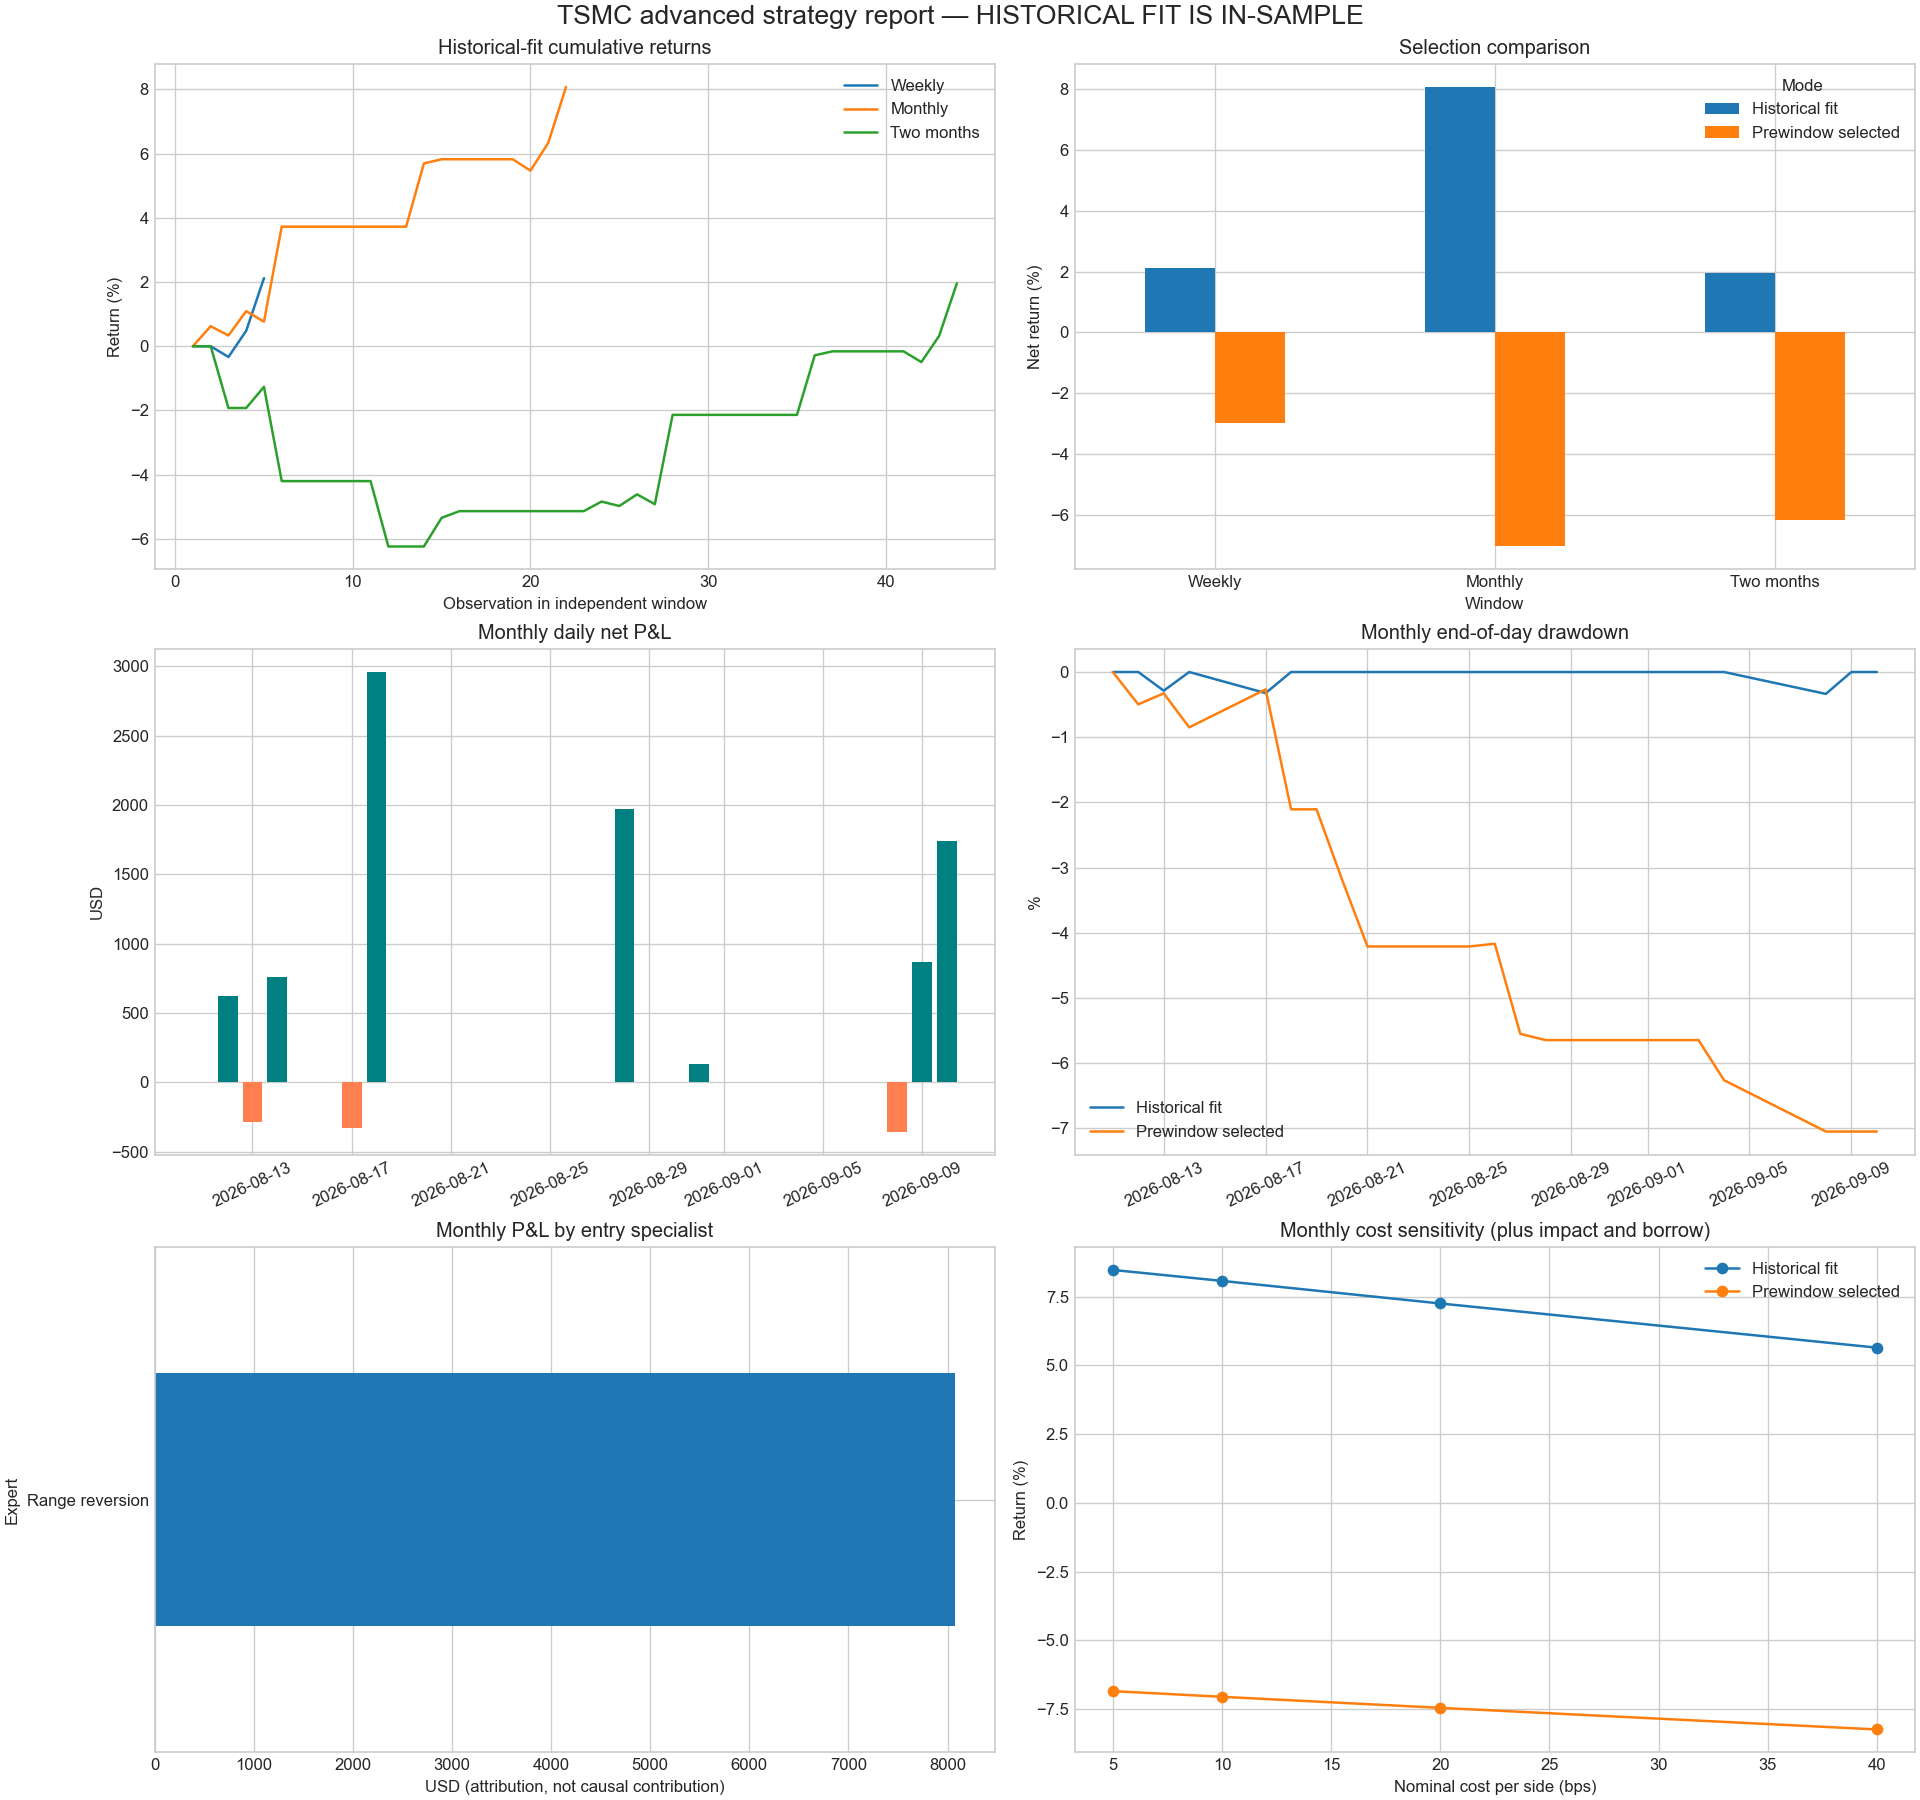

In [ ]:
from IPython.display import HTML
import io,base64,html
fig,axes=plt.subplots(3,2,figsize=(16,15),constrained_layout=True)
fig.suptitle('TSMC advanced strategy report — HISTORICAL FIT IS IN-SAMPLE',fontsize=16)
for label in ['Weekly','Monthly','Two months']:
    curve=results[('Historical fit',label)][1]
    axes[0,0].plot(range(1,len(curve)+1),100*(curve.Equity/INITIAL_CAPITAL-1),label=label)
axes[0,0].set(title='Historical-fit cumulative returns',xlabel='Observation in independent window',ylabel='Return (%)');axes[0,0].legend()
summary.pivot(index='Window',columns='Mode',values='Return_pct').reindex(['Weekly','Monthly','Two months']).plot.bar(ax=axes[0,1],rot=0)
axes[0,1].set(title='Selection comparison',ylabel='Net return (%)')
stat,curve,trades,fills=results[('Historical fit','Monthly')]
axes[1,0].bar(curve.Date,curve.Daily_PnL,color=np.where(curve.Daily_PnL>=0,'teal','coral'))
axes[1,0].set(title='Monthly daily net P&L',ylabel='USD')
for mode in choices:
    c=results[(mode,'Monthly')][1]
    axes[1,1].plot(c.Date,100*c.Drawdown,label=mode)
axes[1,1].set(title='Monthly end-of-day drawdown',ylabel='%');axes[1,1].legend()
if len(trades):
    trades.groupby('Expert').Net_PnL.sum().sort_values().plot.barh(ax=axes[2,0])
axes[2,0].set(title='Monthly P&L by entry specialist',xlabel='USD (attribution, not causal contribution)')
stress=[]
for mode,idx in choices.items():
    cfg=configs[idx]
    for bps in [5,10,20,40]:
        st=engine(prices,features,scores[cfg['profile']],contributions[cfg['profile']],cfg,len(prices)-22,len(prices),INITIAL_CAPITAL,bps)
        stress.append(dict(Mode=mode,Cost_bps=bps,Monthly_return_pct=100*st['Return']))
stress=pd.DataFrame(stress)
for mode,g in stress.groupby('Mode'):
    axes[2,1].plot(g.Cost_bps,g.Monthly_return_pct,marker='o',label=mode)
axes[2,1].set(title='Monthly cost sensitivity (plus impact and borrow)',xlabel='Nominal cost per side (bps)',ylabel='Return (%)');axes[2,1].legend()
for ax in axes[1]: ax.tick_params(axis='x',rotation=25)
buffer=io.BytesIO();fig.savefig(buffer,format='png',dpi=120);chart=base64.b64encode(buffer.getvalue()).decode();plt.close(fig)
monthly=summary[(summary.Mode=='Historical fit')&(summary.Window=='Monthly')].iloc[0]
header=f"<h1>TSMC advanced trading report</h1><h2>Monthly historical-fit profit: ${monthly.Net_profit:,.2f} ({monthly.Return_pct:.2f}%)</h2>"
warning='<p class="warning"><b>Selected using these same historical windows.</b> Earlier-selected results are shown separately. More complexity does not establish future profitability.</p>'
sections=[header,warning,summary.round(3).to_html(index=False),f'<img width="100%" src="data:image/png;base64,{chart}">']
tables={'Summary':summary,'Selected rules':selection.reset_index(),'Cost sensitivity':stress,'Forecast audit':audit}
for (mode,label),(st,cv,tr,fl) in results.items():
    for kind,table in [('Equity',cv),('Trades',tr),('Fills',fl)]:
        key=f'{mode} {label} {kind}'
        tables[key]=table
        sections.append(f'<details><summary>{html.escape(key)}</summary>{table.round(4).to_html(index=False)}</details>')
sections.append('<h2>Selected rules and earlier returns</h2>'+selection.round(4).to_html())
sections.append('<details><summary>All candidate configurations</summary>'+candidates.round(4).to_html()+'</details>')
tables['Candidates']=candidates.reset_index()
sections.append('<h2>Execution assumptions</h2><p>Whole shares; next-open entries; partial 1R exits; prior-day trailing stops; gap-through stops at open; stop-first ambiguous daily bars; nominal commission/slippage plus participation impact; short borrow 3%/252 per session. No dividend or tax adjustment. Zero end-of-day drawdown does not mean no intraday risk. Buy-and-hold is a fractional-share benchmark with nominal entry/exit costs only.</p>')
sections.append('<p>Refresh: Run All in the notebook. The HTML report is regenerated; the final notebook cell refreshes the Excel snapshot when the bundled report runtime is available.</p>')
style='<style>body{font:15px Arial;margin:32px;color:#172b4d}h1,h2{color:#183153}table{border-collapse:collapse;font-size:12px;margin:15px 0}th{background:#183153;color:white}td,th{padding:8px;border-bottom:1px solid #ddd}details{margin:14px 0;overflow:auto}summary{cursor:pointer;font-weight:bold}.warning{background:#fff3cd;padding:16px}</style>'
report=style+''.join(sections)
(OUTPUT_DIR/'TSMC_Advanced_Report.html').write_text(report,encoding='utf-8')
# One machine-readable bundle powers the consolidated Excel workbook; no scattered CSVs.
payload={name:json.loads(table.to_json(orient='split',date_format='iso')) for name,table in tables.items()}
(OUTPUT_DIR.parent/'.advanced_build'/'report_data.json').write_text(json.dumps(payload),encoding='utf-8')
display(HTML(report))
print('Consolidated report:',OUTPUT_DIR/'TSMC_Advanced_Report.html')


In [ ]:
# Refresh the single Excel report after the HTML report; all research remains in this notebook.
import subprocess
node = Path.home()/'.cache/codex-runtimes/codex-primary-runtime/dependencies/node/bin/node.exe'
builder = OUTPUT_DIR.parent/'.advanced_build/report.mjs'
if node.exists() and builder.exists():
    completed = subprocess.run([str(node),str(builder)],capture_output=True,text=True)
    if completed.returncode:
        raise RuntimeError('Excel refresh failed: '+completed.stderr)
    print('Excel report refreshed:', OUTPUT_DIR/'TSMC_Advanced_Report.xlsx')
else:
    print('HTML report is current. Excel refresh needs the bundled Node/artifact-tool runtime and report.mjs.')


Excel report refreshed: F:\SEM-7\Time Series Analysis\Project\Trading\advanced_report\TSMC_Advanced_Report.xlsx
